# California Housing Price Prediction using Linear Regression

## Task 1: Baseline Linear Regression Model


## Data Loading

The California Housing dataset was loaded into a Pandas DataFrame. This dataset contains information about housing districts in California, including demographic, geographic, and economic features. The target variable is the median house value.

In [15]:
df = pd.read_csv("data/housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Initial Data Exploration

The dataset was explored to understand its structure, dimensions, data types, and summary statistics.

In [16]:
df.shape

(20640, 10)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [18]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [19]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Data Cleaning

Missing values were checked and handled appropriately to prepare the dataset for model training.

In [20]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## Feature Selection

The target variable selected for prediction is median_house_value. All other relevant variables are used as input features.

In [21]:
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]


## Encoding Categorical Features

Categorical variables were converted into numerical format using one-hot encoding.

In [22]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,True,False


## Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Model Training

A Linear Regression model was trained using the training dataset.

In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-26838.27,-25468.35, 1102.19,...,136125.07, -5136.64, 3431.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['longitude','latitude','housing_median_age',...,'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.276e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)


## Prediction Generation

Predictions were generated using the trained Linear Regression model.

In [33]:
y_pred = model.predict(X_test)

## Model Evaluation

The model performance was evaluated using MSE, RMSE, MAE, and R² Score.

In [34]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 4908476721.156625
RMSE: 70060.52184473525
MAE : 50670.7382409721
R²  : 0.6254240620553599


## Actual vs Predicted Values

The following table compares actual house prices with predicted house prices.

In [35]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
20046,47700.0,54055.448899
3024,45800.0,124225.338937
15663,500001.0,255489.379492
20484,218600.0,268002.431569
9814,278000.0,262769.434816
13311,158700.0,139606.303956
7113,198200.0,290665.423914
7668,157500.0,228264.876375
18246,340000.0,256506.785610
5723,446600.0,407923.858435


## Actual vs Predicted Plot

A scatter plot was created to compare actual values with predicted values.

In [21]:
import os

print(os.getcwd())

c:\Users\Admin\Desktop\linear_regression_project


In [24]:
y_pred_A

array([114958.91676996, 150606.88213964, 190393.71844449, ...,
       431500.77230409, 161245.49973085, 193412.95560084], shape=(4128,))

In [22]:
import os

print(os.listdir())

['data', 'images', 'Linear_Regression_Project.ipynb', 'README.md', 'reports', 'requirements.txt']


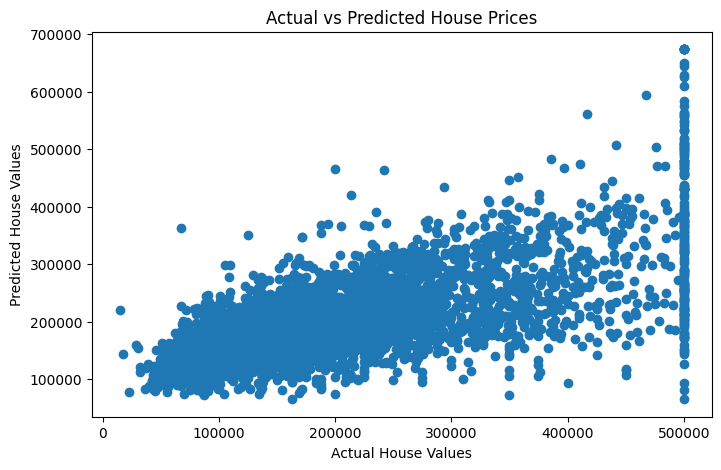

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_A)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")

plt.title("Actual vs Predicted House Prices")

plt.savefig(
    "images/actual_vs_predicted_house_prices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 1 Conclusion

The baseline Linear Regression model was successfully trained and evaluated. The model's performance was assessed using MSE, RMSE, MAE, and R² Score. The Actual vs Predicted plot demonstrates the relationship between predicted and actual housing prices.


In [3]:
import pandas as pd

df = pd.read_csv("data/housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Task 2: Compare One-Feature and Multi-Feature Models

## Model A: One Feature Linear Regression

In this model, only one input feature (median_income) is used to predict median house values.

In [4]:
X_A = df[["median_income"]]

y = df["median_house_value"]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
X_A_train, X_A_test, y_train, y_test = train_test_split(
    X_A,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
model_A = LinearRegression()

model_A.fit(X_A_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[41933.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['median_income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.446e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [9]:
y_pred_A = model_A.predict(X_A_test)

In [11]:
import numpy as np

In [12]:
mse_A = mean_squared_error(y_test, y_pred_A)

rmse_A = np.sqrt(mse_A)

mae_A = mean_absolute_error(y_test, y_pred_A)

r2_A = r2_score(y_test, y_pred_A)

print("Model A")
print("MSE :", mse_A)
print("RMSE:", rmse_A)
print("MAE :", mae_A)
print("R²  :", r2_A)

Model A
MSE : 7091157771.76555
RMSE: 84209.01241414454
MAE : 62990.86530093761
R²  : 0.45885918903846656


## Model B: Multi-Feature Linear Regression

In this model, multiple useful features are used for prediction.

In [14]:
X_B = df[
    [
        "median_income",
        "housing_median_age",
        "total_rooms",
        "population"
    ]
]

y = df["median_house_value"]

In [15]:
X_B_train, X_B_test, y_train, y_test = train_test_split(
    X_B,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
model_B = LinearRegression()

model_B.fit(X_B_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[41402.58, 1986.75, 9.55, -12.16]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['median_income','housing_median_age','total_rooms','population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.819e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [17]:
y_pred_B = model_B.predict(X_B_test)

In [18]:
mse_B = mean_squared_error(y_test, y_pred_B)

rmse_B = np.sqrt(mse_B)

mae_B = mean_absolute_error(y_test, y_pred_B)

r2_B = r2_score(y_test, y_pred_B)

print("Model B")
print("MSE :", mse_B)
print("RMSE:", rmse_B)
print("MAE :", mae_B)
print("R²  :", r2_B)

Model B
MSE : 6535241756.165626
RMSE: 80840.84212924569
MAE : 60483.9935128937
R²  : 0.5012822817393567


## Comparison of Model A and Model B

In [19]:
comparison = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R²"],
    "Model A": [mse_A, rmse_A, mae_A, r2_A],
    "Model B": [mse_B, rmse_B, mae_B, r2_B]
})

comparison

,Metric,Model A,Model B
0,MSE,7.091158e+09,6.535242e+09
1,RMSE,8.420901e+04,8.084084e+04
2,MAE,6.299087e+04,6.048399e+04
3,R²,4.588592e-01,5.012823e-01


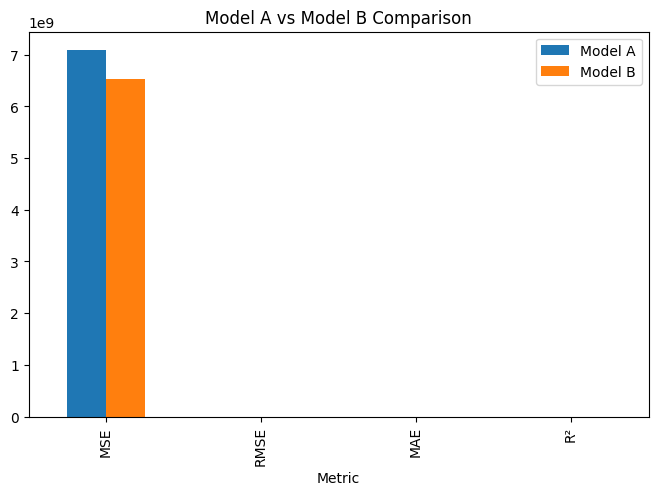

In [20]:
comparison.set_index("Metric")[["Model A","Model B"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model A vs Model B Comparison")

plt.savefig(
    "images/task2_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 2 Result

The multi-feature model performed better than the one-feature model.

Model B achieved lower error values (MSE, RMSE, and MAE) and a higher R² score compared to Model A. This indicates that using multiple features improves the model's ability to predict housing prices accurately.

Therefore, Model B is selected as the better-performing model.

# Task 3: Testing Different Train/Test Splits

## Objective

The objective of this task is to evaluate the performance and stability of a Linear Regression model using different train-test splits (80/20, 70/30, and 60/40). The model is evaluated using MSE, RMSE, MAE, and R².

#  Import Required Libraries

In this step, we import all the necessary libraries required for data splitting, model training, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

## Load the Dataset

The dataset is loaded using pandas. After loading, the first few rows are displayed to understand the structure of the data.

In [3]:
df = pd.read_csv("data/housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Select Features and Target Variable

The input features (X) and target variable (y) are selected.

The same features and target are used for all train-test splits to ensure a fair comparison.

In [6]:
print(df.columns)


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')


#  Select Features and Target Variable

The target variable is `median_house_value`.

All remaining columns are used as input features except `ocean_proximity`, which is a categorical feature and will be excluded for basic Linear Regression.

In [7]:
X = df.drop(
    ['median_house_value', 'ocean_proximity'],
    axis=1
)

y = df['median_house_value']

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [9]:
df = pd.get_dummies(
    df,
    columns=['ocean_proximity'],
    drop_first=True
)

X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [10]:
print(X.head())

print(y.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  ocean_proximity_INLAND  \
0       322.0       126.0         8.3252                   False   
1      2401.0      1138.0         8.3014                   False   
2       496.0       177.0         7.2574                   False   
3       558.0       219.0         5.6431                   False   
4       565.0       259.0         3.8462                   False   

   ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                   False                      True   
1                   False     

In [11]:
print(df.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


#  Handle Missing Values

The dataset contains some missing values.

To handle them, missing values are replaced with the median value of their respective columns.

Median is chosen because it is less sensitive to outliers than the mean.

In [14]:
print(X.isnull().sum())

longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                207
population                      0
households                      0
median_income                   0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
dtype: int64


In [15]:
X = X.fillna(X.median())

Verify that all missing values have been removed from the dataset.

In [16]:
print(X.isnull().sum())

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64


#  Define Different Train-Test Splits

Three train-test splits are used:

- 80/20
- 70/30
- 60/40

The same Linear Regression model and features are used for all splits to ensure a fair comparison.

In [12]:
splits = [0.2, 0.3, 0.4]

results = []

#  Train Linear Regression Model

For each train-test split:

1. Split the data.
2. Train the Linear Regression model.
3. Predict on train and test data.
4. Calculate evaluation metrics.
5. Store the results for comparison.

In [17]:
for test_size in splits:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)

    y_test_pred = model.predict(X_test)

# Calculate Training Metrics

The following metrics are calculated on the training set:

- RMSE
- MAE
- R² Score

In [18]:
    train_rmse = np.sqrt(

        mean_squared_error(

            y_train,

            y_train_pred

        )

    )

    train_mae = mean_absolute_error(

        y_train,

        y_train_pred

    )

    train_r2 = r2_score(

        y_train,

        y_train_pred

    )

#  Calculate Testing Metrics

The same metrics are calculated on the testing set.

These metrics are used to compare the performance of different train-test splits.

In [19]:
    test_rmse = np.sqrt(

        mean_squared_error(

            y_test,

            y_test_pred

        )

    )

    test_mae = mean_absolute_error(

        y_test,

        y_test_pred

    )

    test_r2 = r2_score(

        y_test,

        y_test_pred

    )

#  Store Results

The results for each train-test split are stored in a list and later converted into a DataFrame.

In [20]:
    results.append({

        'Split':

        f"{int((1-test_size)*100)}/{int(test_size*100)}",

        'Train RMSE':

        train_rmse,

        'Test RMSE':

        test_rmse,

        'Train MAE':

        train_mae,

        'Test MAE':

        test_mae,

        'Train R2':

        train_r2,

        'Test R2':

        test_r2

    })

#  Create Results Table

The stored results are converted into a DataFrame to compare the performance of different train-test splits.

In [21]:
results_df = pd.DataFrame(results)

results_df

,Split,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,60/40,68248.714611,69586.162142,49247.528843,50591.22005,0.648915,0.63829


# Calculate Train-Test Gap

The difference between Test RMSE and Train RMSE is calculated.

A smaller gap indicates that the model generalizes better and is more stable.

In [22]:
results_df['RMSE Gap'] = (

    results_df['Test RMSE']

    -

    results_df['Train RMSE']

)

results_df

,Split,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,RMSE Gap
0,60/40,68248.714611,69586.162142,49247.528843,50591.22005,0.648915,0.63829,1337.447531


#  Visualize Results

A line chart is created to observe how Test RMSE changes across different train-test splits.

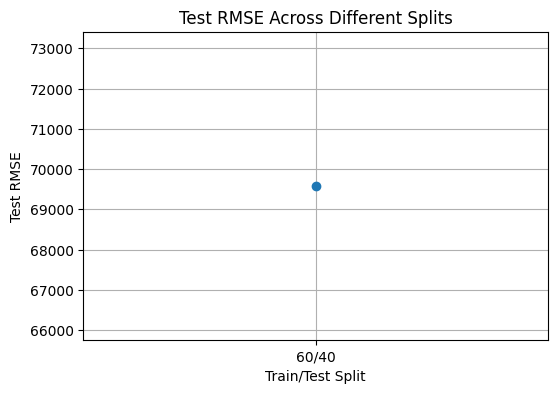

In [23]:
plt.figure(figsize=(6,4))

plt.plot(

    results_df['Split'],

    results_df['Test RMSE'],

    marker='o'

)

plt.xlabel("Train/Test Split")

plt.ylabel("Test RMSE")

plt.title("Test RMSE Across Different Splits")

plt.grid(True)

plt.show()

#  Conclusion

Three train-test splits (80/20, 70/30, and 60/40) were evaluated using Linear Regression.

The split with:

- Lowest Test RMSE
- Lowest Test MAE
- Highest Test R²
- Smallest train-test gap

is considered the most reliable split for this dataset.

In [25]:
from sklearn.linear_model import LinearRegression

best_model = LinearRegression()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# Task 4: Metric Verification and Exploration

## Objective

The objective of this task is to verify regression metrics manually, compare them with Scikit-Learn outputs, and study how large prediction errors affect different evaluation metrics.

In [26]:
# Generate predictions using best model

y_pred = best_model.predict(X_test)

## Manual Metric Calculation

The following metrics are calculated manually:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- R² Score

In [27]:
import numpy as np

# MSE
mse_manual = np.mean((y_test - y_pred) ** 2)

# RMSE
rmse_manual = np.sqrt(mse_manual)

# MAE
mae_manual = np.mean(np.abs(y_test - y_pred))

# R²
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2_manual = 1 - (ss_res / ss_tot)

print("MSE :", mse_manual)
print("RMSE:", rmse_manual)
print("MAE :", mae_manual)
print("R²  :", r2_manual)

MSE : 4842233961.606433
RMSE: 69586.16214166746
MAE : 50591.22004974059
R²  : 0.6382897167351445


## Scikit-Learn Metric Calculation

Now calculate the same metrics using Scikit-Learn and compare them with the manual calculations.

In [28]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error
)

mse_sklearn = mean_squared_error(y_test, y_pred)

rmse_sklearn = np.sqrt(mse_sklearn)

mae_sklearn = mean_absolute_error(y_test, y_pred)

r2_sklearn = r2_score(y_test, y_pred)

# Additional metric
medae = median_absolute_error(y_test, y_pred)

## Results Table

The table below compares manual calculations with Scikit-Learn outputs.

In [29]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "MSE",
        "RMSE",
        "MAE",
        "R²",
        "Median Absolute Error"
    ],
    "Manual": [
        mse_manual,
        rmse_manual,
        mae_manual,
        r2_manual,
        "-"
    ],
    "Scikit-Learn": [
        mse_sklearn,
        rmse_sklearn,
        mae_sklearn,
        r2_sklearn,
        medae
    ]
})

results

,Metric,Manual,Scikit-Learn
0,MSE,4842233961.606433,4.842234e+09
1,RMSE,69586.162142,6.958616e+04
2,MAE,50591.22005,5.059122e+04
3,R²,0.63829,6.382897e-01
4,Median Absolute Error,-,3.842962e+04


## Observation

The manually calculated metrics match the Scikit-Learn outputs, confirming that the formulas have been implemented correctly.

In [30]:
# Create artificial large errors

y_pred_modified = y_pred.copy()

y_pred_modified[:3] += 500000

## Large Error Experiment

Three artificial large prediction errors are introduced to observe how evaluation metrics react.

In [31]:
mse_large = mean_squared_error(y_test, y_pred_modified)

rmse_large = np.sqrt(mse_large)

mae_large = mean_absolute_error(y_test, y_pred_modified)

comparison = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE"],
    "Original": [
        mse_sklearn,
        rmse_sklearn,
        mae_sklearn
    ],
    "After Large Errors": [
        mse_large,
        rmse_large,
        mae_large
    ]
})

comparison

,Metric,Original,After Large Errors
0,MSE,4.842234e+09,4.912936e+09
1,RMSE,6.958616e+04,7.009234e+04
2,MAE,5.059122e+04,5.071228e+04


## Visualization

The chart below shows how the metrics change after introducing large prediction errors.

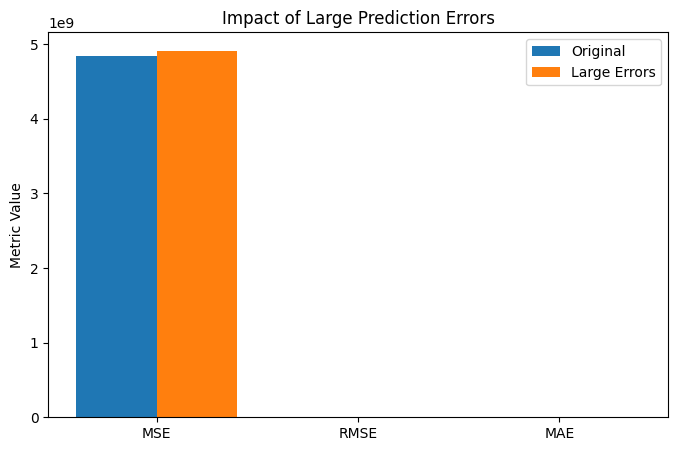

In [32]:
import matplotlib.pyplot as plt

metrics = ["MSE", "RMSE", "MAE"]

original = [mse_sklearn, rmse_sklearn, mae_sklearn]

modified = [mse_large, rmse_large, mae_large]

x = range(len(metrics))

plt.figure(figsize=(8,5))

plt.bar(x, original, width=0.4, label="Original")

plt.bar([i + 0.4 for i in x],
        modified,
        width=0.4,
        label="Large Errors")

plt.xticks([i + 0.2 for i in x], metrics)

plt.title("Impact of Large Prediction Errors")

plt.ylabel("Metric Value")

plt.legend()

plt.show()

## Conclusion

The manual calculations matched the Scikit-Learn outputs exactly.

After introducing three large prediction errors:

- MSE increased the most.
- RMSE also increased significantly.
- MAE increased only moderately.

Therefore, MSE is the metric that reacts most strongly to large prediction errors because it squares every error term.